# 04 — Analysis of the test results

This notebook trains nothing: it reads the results of the test runs saved by `03_nas.ipynb` and produces the tables and the figure of Secs. 4.4 and 4.5 of the report.

**Inputs:** `risultati_test.csv` (test AUC and AP of 9 architectures × seeds 1–5) and `punteggi_test.npz` (scores of each run on the test windows, key `"<architecture>_seed<s>_test"`, and on the straddling windows, key `"<architecture>_seed<s>_cav"`, plus the test labels `y_test`).

**Output:** `roc_pr_test.pdf` (Fig. 6).

**Naming.** `larghezze` = widths of the hidden layers (the name of an architecture, e.g. `"16-128-16-128"`), `n_param` = number of parameters, `righe` = rows, `cav` = straddling windows, `neg` / `pos` = negative / positive test windows.

## 1. Test AUC and AP (Table 9)

Mean and standard error over the five seeds, for each architecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

# The column of the architectures is read as text, so that "16" stays a string
df_te = pd.read_csv("risultati_test.csv", dtype={"larghezze": str})
P = np.load("punteggi_test.npz")
y_test = P["y_test"]

# Mean and standard deviation over the five seeds, sorted by number of parameters
tab = (df_te.groupby("larghezze")
            .agg(n_param=("n_param", "first"),
                 auc_test=("auc_test", "mean"), auc_std=("auc_test", "std"),
                 ap_test=("ap_test", "mean"), ap_std=("ap_test", "std"))
            .sort_values("n_param")
            .reset_index())
# Standard error of the mean = standard deviation / sqrt(number of seeds)
tab["auc_se"] = tab["auc_std"] / np.sqrt(5)
tab["ap_se"] = tab["ap_std"] / np.sqrt(5)
print(tab[["larghezze", "n_param", "auc_test", "auc_se", "ap_test", "ap_se"]]
      .to_string(index=False, float_format="%.4f"))

      larghezze  n_param  auc_test  auc_se  ap_test  ap_se
             16     1953    0.8861  0.0013   0.2924 0.0055
       16-16-16     2497    0.8972  0.0044   0.4166 0.0176
    16-32-16-16     3297    0.9025  0.0025   0.4310 0.0065
    16-32-32-64     5713    0.9009  0.0040   0.4423 0.0062
  16-128-16-128     8481    0.9022  0.0016   0.4572 0.0036
          64-64    11969    0.8918  0.0008   0.3281 0.0040
  16-64-256-128    52689    0.9035  0.0025   0.4413 0.0148
  16-256-256-64    88593    0.9025  0.0010   0.4621 0.0083
256-256-256-256   228609    0.8916  0.0015   0.3477 0.0124


## 2. ROC and precision–recall curves (Fig. 6)

The baseline and two architectures of the front, one thin line per seed.

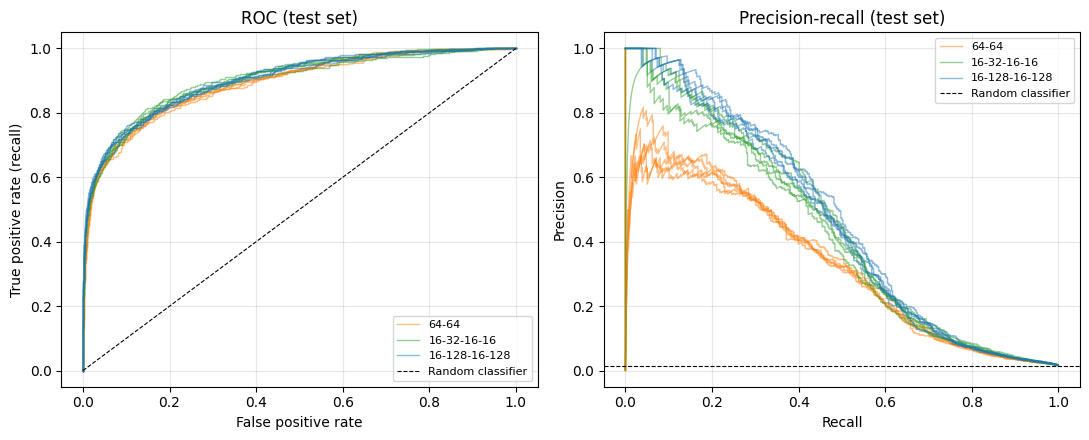

In [2]:
# Architectures to show and their colours
DA_MOSTRARE = {"64-64": "tab:orange",
               "16-32-16-16": "tab:green",
               "16-128-16-128": "tab:blue"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for k, colore in DA_MOSTRARE.items():
    for s in [1, 2, 3, 4, 5]:
        p = P[f"{k}_seed{s}_test"]                       # scores of this run on the test windows
        fpr, tpr, _ = roc_curve(y_test, p)
        prec, rec, _ = precision_recall_curve(y_test, p)
        etichetta = k if s == 1 else None                # one legend entry per architecture
        ax1.plot(fpr, tpr, color=colore, alpha=0.5, lw=1, label=etichetta)
        ax2.plot(rec, prec, color=colore, alpha=0.5, lw=1, label=etichetta)

# Random classifier: the diagonal in the ROC plane
ax1.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random classifier")
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate (recall)")
ax1.set_title("ROC (test set)"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# Random classifier: precision equal to the fraction of positive windows
ax2.axhline(y_test.mean(), color="k", ls="--", lw=0.8, label="Random classifier")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-recall (test set)"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_test.pdf", bbox_inches="tight")
plt.show()

## 3. Precision at a recall of 50% (Table 9)

For each run, the highest precision among the thresholds that detect at least half of the positive windows; then mean and standard error over the five seeds.

In [3]:
def precision_a_recall(y, p, recall_minimo=0.5):
    """Highest precision among the thresholds with a recall of at least `recall_minimo`."""
    prec, rec, _ = precision_recall_curve(y, p)
    return prec[rec >= recall_minimo].max()

righe = []
for k in tab["larghezze"]:
    valori = [precision_a_recall(y_test, P[f"{k}_seed{s}_test"]) for s in [1, 2, 3, 4, 5]]
    righe.append({"larghezze": k, "n_param": tab.loc[tab["larghezze"] == k, "n_param"].iloc[0],
                  "prec_a_recall50": np.mean(valori),
                  "se": np.std(valori, ddof=1) / np.sqrt(5)})
print(pd.DataFrame(righe).to_string(index=False, float_format="%.4f"))

      larghezze  n_param  prec_a_recall50     se
             16     1953           0.2871 0.0083
       16-16-16     2497           0.3862 0.0135
    16-32-16-16     3297           0.4089 0.0175
    16-32-32-64     5713           0.4138 0.0082
  16-128-16-128     8481           0.4365 0.0107
          64-64    11969           0.3268 0.0055
  16-64-256-128    52689           0.4405 0.0148
  16-256-256-64    88593           0.4589 0.0207
256-256-256-256   228609           0.3143 0.0151


## 4. Control on the straddling windows (Sec. 4.5)

The 468 straddling windows of the test set contain a lane crossing and were never used for training. For each run we compute the AUC obtained by ranking them against the negative test windows, and the median score of the negative, positive and straddling windows. The values are then averaged over the five seeds.

In [4]:
neg = (y_test == 0)
pos = (y_test == 1)

righe_cav = []
for k in tab["larghezze"]:
    for s in [1, 2, 3, 4, 5]:
        p_te = P[f"{k}_seed{s}_test"]                    # scores on the test windows
        p_cav = P[f"{k}_seed{s}_cav"]                    # scores on the straddling windows
        # Straddling windows (label 1) against the negative test windows (label 0)
        y_mix = np.r_[np.ones(len(p_cav)), np.zeros(neg.sum())]
        s_mix = np.r_[p_cav, p_te[neg]]
        righe_cav.append({"larghezze": k,
                          "auc_cav_vs_neg": roc_auc_score(y_mix, s_mix),
                          "med_neg": np.median(p_te[neg]),
                          "med_pos": np.median(p_te[pos]),
                          "med_cav": np.median(p_cav)})

# Mean over the five seeds, in the same order as the table above
cav = (pd.DataFrame(righe_cav).groupby("larghezze").mean()
         .reindex(tab["larghezze"]).reset_index())
cav["auc_test"] = tab["auc_test"].values                 # ordinary test AUC, for comparison
print(cav.to_string(index=False, float_format="%.4f"))

      larghezze  auc_cav_vs_neg  med_neg  med_pos  med_cav  auc_test
             16          0.9840   0.1484   0.8751   0.9819    0.8861
       16-16-16          0.9671   0.1114   0.9202   0.9758    0.8972
    16-32-16-16          0.9544   0.0811   0.9243   0.9813    0.9025
    16-32-32-64          0.9423   0.1029   0.9330   0.9771    0.9009
  16-128-16-128          0.9506   0.0738   0.9354   0.9831    0.9022
          64-64          0.9803   0.1393   0.8809   0.9773    0.8918
  16-64-256-128          0.9652   0.1003   0.9324   0.9795    0.9035
  16-256-256-64          0.9686   0.1117   0.9383   0.9792    0.9025
256-256-256-256          0.9708   0.1229   0.8688   0.9577    0.8916
